In [ ]:
#this AI model, given a sparring video, will assess joint mobility and injury risk, thereby informing a user if their technique and methods
#are safe. In the heat of the moment, sparrers will often sacrifice technique for speed; but this model will allow them to analyze and replay unsafe patterns
#and improve daily during training sessions.

In [ ]:
#parameters:

#knee flexion (angle at knee, bentness at landing) (hip, knee, ankle)
#knee valgus (measuring the level knee is collapsing inward through an angle) (hip, knee, ankle)
#hip-knee alignment (whether knee is right under hip, also angle) (hip, knee, ankle)
#pelvic tilt (is one hip higher than the other one) (both hips)

#elbow extension (angle at elbow when striking, watching out for hyperextension) (shoulder, elbow, wrist)
#shoulder asymmetry (are shoulders level, angle) (both shoulders)
#shoulder-hip alignment (are shoulders directly above hips, also angle) (shoulder, hip)
#elbow-to-body distance (measuring guard) (elbow, hip)

#trunk rotation (upper body twist vs lower body twist, angle) (midpoint between shoulders, midpoint between hips)
#spinal alignment (hip to shoulder, how straight?) (shoulder midpoint, hip midpoint)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gLTaR0vQgROIbVkctCnU")
project = rf.workspace("dhritis-workspace-3jrp5").project("boxing-r3kow-d1c6l")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gLTaR0vQgROIbVkctCnU")
project = rf.workspace("dhritis-workspace-3jrp5").project("boxing-ljy1m-drlbs")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gLTaR0vQgROIbVkctCnU")
project = rf.workspace("dhritis-workspace-3jrp5").project("taekwondo-movements_2-qrlwu")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gLTaR0vQgROIbVkctCnU")
project = rf.workspace("dhritis-workspace-3jrp5").project("taekwondo-movements-y2isc")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gLTaR0vQgROIbVkctCnU")
project = rf.workspace("dhritis-workspace-3jrp5").project("taekwondo-khq7c-chilg")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gLTaR0vQgROIbVkctCnU")
project = rf.workspace("dhritis-workspace-3jrp5").project("taekwondo-movements_3-4wgt2")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gLTaR0vQgROIbVkctCnU")
project = rf.workspace("dhritis-workspace-3jrp5").project("taekwondo-movements_4-m1qod")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gLTaR0vQgROIbVkctCnU")
project = rf.workspace("dhritis-workspace-3jrp5").project("taekwondo-movements_1-6qzqh")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gLTaR0vQgROIbVkctCnU")
project = rf.workspace("dhritis-workspace-3jrp5").project("taekwondo-pose-zz9lu")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
#commented out; this is the initial un-augmented taekwondo dataset i downloaded for testing the image-cleanup/filter pipeline

# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="gLTaR0vQgROIbVkctCnU")
# project = rf.workspace("dhritis-workspace-3jrp5").project("taekwondo-movements-ailud")
# version = project.version(1)
# dataset = version.download("yolov8")


In [ ]:
#changed from mediapipe to YOLOv8; has 17 keypoints (like body points, knee, ankle, etc) but it's way easier to deal with and I was having
#a bunch of compatibility problems with mediapipe
!pip install ultralytics opencv-python numpy matplotlib

In [ ]:
import cv2 #opencv
from ultralytics import YOLO #pose estimation
import numpy as np
import matplotlib.pyplot as plt


#setting the model, using YOLOv8, the n stands for nano. v8 isn't the most recent, but it's been out since 2023
#so it's way easier to troubleshoot
model = YOLO('yolov8n-pose.pt')


In [ ]:
#filtering out ghost detections by discounting bounding boxes that are really small (ghost detections occur
#in areas of close contact, so by definition those bounding boxes are small)

#results, the image analysis we got from YOLO, also automatically generates border boxes from YOLO
#problem is, that returns multiple formats, so .xyxy gives the top left and bottom right points
#for each person; width, height, and therefore box area are calculable from there
#still one more thing though; .xyxy gives tensor format, which is harder to deal with compared to a list
#so, just .tolist()

#now i'm going to loop the area formula for each person's bounding box (each nested list)
#eliminating everyone less than a certain threshold proportional to image, otherwise
#ghost detections throw this off.

#bounding_boxes = results.boxes.xyxy.tolist()

#this gives a list of lists; each nested list is one person's box
#within the nested lists; it goes northwest x value, northwest y, southeast x, southeast y assuming rectangle

#center zoning is not going to work, because sometimes athletes on the edge of the ring

#result is full YOLO output for ONE image
def cut_ghosts(result):
  areas = []
  #stopped treating like a list because this function itself will be looped
  #to batch process images
  image_height, image_width = result.orig_shape
  area_threshold = 0.025 * (image_height * image_width)

  bounding_boxes = result.boxes.xyxy.tolist()
  for i in range (len(bounding_boxes)):
    width = bounding_boxes[i][2]-bounding_boxes[i][0]
    width = abs(width)

    height = bounding_boxes[i][3]-bounding_boxes[i][1]
    height=abs(height)
    area = width * height

    if area > area_threshold:
      areas.append([area,i])

  #can't just take the index of the element in areas: eg areas[0] is the first person detected
  #some people were cut out because they were too small, so it's not necessarily in order
  indices = []
  for nested_list in areas:
    index = nested_list[1]
    indices.append(index)

  return indices

In [ ]:
#single result for one image being passed in with the passing indices from
def filter_by_confidence(result, indices):
  if not indices:
    return []

  confident_indices = []
  for index in indices:
    person_keypoint_average = []
    #taking only the people that have already passed cut_ghosts
    model_output = result.keypoints.data[index]
    model_output = model_output.tolist()

    #and then taking the confidence for each keypoint that YOLO itself gives
    number_confident = 0
    for keypoint_data in model_output:
      person_keypoint_average.append(keypoint_data[2])
      #keypoint data at 2 because it gives x (horizontal coordinate in pixels), y (vertical), and then confidence
      #between 0 and 1
      #only keeping keypoints that have at least 60% confidence
      if keypoint_data[2] > 0.55:
        number_confident += 1
    #print(sum(person_keypoint_average)/len(person_keypoint_average))
    if number_confident >= 10:
      confident_indices.append(index)

  return confident_indices


In [ ]:
#wrote this after cut_ghosts, which is why it isn't incorporated there;
#same exact thing, but i didn't want to bulk up eliminate_overlap
def box_area(box):
  width = abs(box[0]-box[2])
  height = abs(box[1]-box[3])
  area = width * height
  return area

In [ ]:
def eliminate_overlap(result, indices):
  if not indices:
    return []

  #using a set this time because automatically ignores duplicates, which is what I want,
  #since comparing B vs A for overlap is the same as comparing A vs B; I could've filtered out the
  #redundancy, but it would've just added complexity, so I took that hit for readability,
  #since anyway I'll only have 4 boxes max and the efficiency won't have a significant effect;
  eliminated_indices = set()
  boxes = result.boxes.xyxy.tolist()

  for person in indices:
    for comparison_person in indices:
      if person == comparison_person:
        continue

      #these variables aren't permanent - they keep changing, so 1 and 2, then 2 and 3, etc;
      #they just store the boxes of each person we're comparing in THIS iteration
      box_a = boxes[person]
      box_b = boxes[comparison_person]

      #taking the x coordinate of the top left point for both boxes; whichever one is larger,
      #or more to the right, is where the overlap must start
      left_overlap = max(box_a[0], box_b[0])
      #and then opposite logic for the bottom right point
      right_overlap = min(box_a[2], box_b[2])

      #technically we should be taking the min; but boxes goes highest to lowest for the y axis,
      #so we're taking the max, which gives whichever one is LOWER
      top_overlap = max(box_a[1], box_b[1])
      bottom_overlap = min(box_a[3], box_b[3])

      width = right_overlap - left_overlap
      height = bottom_overlap - top_overlap

      #eliminating negatives from no overlap
      width = max(0, width)
      height = max(0, height)

      overlap_area = height * width
      #subtacting overlap_area so it doesn't get counted twice, both for box a AND box b
      combined_area = box_area(box_a) + box_area(box_b) - overlap_area
      if combined_area == 0:
        continue
      relative_overlap = overlap_area/combined_area

      if relative_overlap > 0.4:
        eliminated_indices.add(person)
        eliminated_indices.add(comparison_person)

  #sorted turns it into a clean, ordered list
  output = sorted(set(indices) - eliminated_indices)
  return output

In [ ]:
#checking if body part ratios are unnatural
def check_anatomy(result, indices):
    if not indices:
      return []

    for person in indices:
      counter = 0
      eliminated_indices = set()

      keypoints_list = result.keypoints.data[person]
      keypoints_list = keypoints_list.tolist()
      lshoulder = keypoints_list[5][:2]
      rshoulder = keypoints_list[6][:2]
      lelbow = keypoints_list[7][:2]
      relbow = keypoints_list[8][:2]
      lwrist = keypoints_list[9][:2]
      rwrist = keypoints_list[10][:2]
      lhip = keypoints_list[11][:2]
      rhip = keypoints_list[12][:2]
      lknee = keypoints_list[13][:2]
      rknee = keypoints_list[14][:2]
      lankle = keypoints_list[15][:2]
      rankle = keypoints_list[16][:2]

      lthigh = calculate_distance(lhip, lknee)
      lshin = calculate_distance(lknee, lankle)
      #so the ratio is always bigger over smaller for consistency
      bigger = max(lthigh, lshin)
      smaller = min(lthigh, lshin)
      ratio = bigger/smaller
      if ratio >= 3:
        counter += 1

      rthigh = calculate_distance(rhip, rknee)
      rshin = calculate_distance(rknee, rankle)
      bigger = max(rthigh, rshin)
      smaller = min(rthigh, rshin)
      ratio = bigger/smaller
      if ratio >= 3:
        counter +=1

      lupperarm = calculate_distance(lshoulder, lelbow)
      lforearm = calculate_distance(lelbow, lwrist)
      bigger = max(lupperarm, lforearm)
      smaller = min(lupperarm, lforearm)
      if ratio >= 3:
        counter += 1

      rupperarm = calculate_distance(rshoulder, relbow)
      rforearm = calculate_distance(relbow, rwrist)
      bigger = max(rupperarm, rforearm)
      smaller = min(rupperarm, rforearm)
      if ratio >= 3:
        counter += 1

      if counter >=2:
        eliminated_indices.add(person)

    output = sorted(set(indices) - eliminated_indices)
    return output

In [ ]:
#got tired of rewriting same code, just made a function for it; same exact thing as before though (deleted old cell)
def test_filters(image_path):
  image = cv2.imread(image_path)
  #verbose is just because i kept getting random decimals and it was confusing
  result = model(image, verbose = False)
  result = result[0]
  indices = cut_ghosts(result)

  #the prints should give the numbers of each detection that passed, omitting the ones that didn't
  print('indices: ', indices)
  confident_indices = filter_by_confidence(result,indices)
  print('confident_indices: ',confident_indices)
  eliminated_indices = eliminate_overlap(result, confident_indices)
  print(f"eliminated_indices: {eliminated_indices}")
  final_indices = check_anatomy(result, eliminated_indices)
  print(f"final_indices: {final_indices}")

  from copy import deepcopy
  filtered = deepcopy(result)
  #setting it equal to .boxes of indices because otherwise it'll take all the areas
  #and then the entire point of cut_ghosts is wasted
  filtered.boxes = filtered.boxes[final_indices]
  plt.imshow(cv2.cvtColor(filtered.plot(),cv2.COLOR_BGR2RGB))
  plt.show()

In [ ]:
#using formula to calculate angle given two points and their midpoint
#useful for pelvic tilt, angle between shoulders, etc

#important to remember start/mid/end are POINTS, not distances
def calculate_angle(start, mid, end):
  #converted to an array for math convenience
  start = np.array(start)
  mid = np.array(mid)
  end = np.array(end)


  v1 = start-mid
  v2 = end-mid
  dot_product = np.dot(v1,v2)
  #general formula; using this because dot product gives you the cosine of the angle
  #between the two vectors, scaled by the product of the lengths. length is irrelevant for this function
  #so divided by the product of the lengths that scaled the dot_product. only using np.linalg.norm
  #to find the vector magnitudes. took the arccos to find the angle, dot_product has cos of angle,
  #not actual angle itself, so took the arccos after the length scaling was taken out
  #if the length scaling wasn't taken out, then dot_product wouldn't be between -1 and 1 and then you couldn't
  #take the cos

  angle_radians = np.arccos((dot_product)/(np.linalg.norm(v1)* np.linalg.norm(v2)))
  angle_degrees = np.degrees(angle_radians)
  return angle_degrees

In [ ]:
def calculate_distance(start,end):
  pythagorean_right = (start[0]-end[0])**2 + (start[1]-end[1])**2
  distance = pythagorean_right**0.5
  return distance

In [ ]:
#gives 0-100 score
def score_parameter(value, safe_limit, zero_point):
  #because for all the parameters i'm using, the bigger the angle, the worse for safety
  if value <= safe_limit:
    score = 100
  elif value >= zero_point:
    score = 0
  else:
    range = abs(safe_limit - zero_point)
    #calculating number of points taken off per integer greater than safe_limit, so it is scaled properly
    point_value = 100/range

    degrees_off = abs(safe_limit-value)
    score = 100 - point_value * degrees_off

  return score

#score_parameter(165,165,180)
#score_parameter(180,165,180)
#score_parameter(172.5,165,180)
#score_parameter(150,165,180)

In [ ]:
def check_joint_confidence(keypoints_list, joint_type, threshold = 0.5):

    #getting keypoint confidences we'll be using
    lshoulder = keypoints_list[5][2]
    rshoulder = keypoints_list[6][2]
    lelbow = keypoints_list[7][2]
    relbow = keypoints_list[8][2]
    lwrist = keypoints_list[9][2]
    rwrist = keypoints_list[10][2]
    lhip = keypoints_list[11][2]
    rhip = keypoints_list[12][2]
    lknee = keypoints_list[13][2]
    rknee = keypoints_list[14][2]
    lankle = keypoints_list[15][2]
    rankle = keypoints_list[16][2]

    if joint_type == 'knee':
      #not only checking if one side is good; because if one side is bad,
      #it's very likely that the other side has swapped or misplaced joints also,
      #and we want the cleanest possible training for the model
      if lhip > threshold and lknee > threshold and lankle > threshold and rhip>threshold and rknee>threshold and rankle>threshold:
        return True
      else:
        return False

    elif joint_type == 'elbow':
      if lshoulder>threshold and lelbow>threshold and lwrist>threshold and rshoulder>threshold and relbow>threshold and rwrist>threshold:
        return True
      else:
        return False

    elif joint_type == 'shoulder':
      if lshoulder>threshold and rshoulder>threshold:
        return True
      else:
        return False

    elif joint_type == 'hip':
      if lhip >threshold and rhip > threshold:
        return True
      else:
        return False

    elif joint_type == 'torso':
      if lshoulder>threshold and rshoulder>threshold and lhip>threshold and rhip>threshold:
        return True
      else:
        return False

In [ ]:
#result is the YOLO image result returning the keypoint and the confidence, indices is the
#list of indexes that are not blurry/work properly, so it's a filtered list of people
#to analyze
def generate_pseudolabels(result, indices):
  total_scores = {}
  for index in indices:
    individual_scores = {}
    #turning into a list- you need .data to get rid of the metadata
    keypoints_list = result.keypoints.data[index]
    keypoints_list = keypoints_list.tolist()

    #getting keypoints we'll be using
    lshoulder = keypoints_list[5][:2]
    rshoulder = keypoints_list[6][:2]
    lelbow = keypoints_list[7][:2]
    relbow = keypoints_list[8][:2]
    lwrist = keypoints_list[9][:2]
    rwrist = keypoints_list[10][:2]
    lhip = keypoints_list[11][:2]
    rhip = keypoints_list[12][:2]
    lknee = keypoints_list[13][:2]
    rknee = keypoints_list[14][:2]
    lankle = keypoints_list[15][:2]
    rankle = keypoints_list[16][:2]

    averaging_scores = []

    if check_joint_confidence(keypoints_list,"knee") == True:
      #print("Knee true")
      left_knee_flexion = calculate_angle(lhip, lknee, lankle)
      right_knee_flexion = calculate_angle(rhip, rknee, rankle)
      worse = max(left_knee_flexion, right_knee_flexion)
      knee_flexion_score = score_parameter(worse, 165, 180)
      averaging_scores.append(knee_flexion_score)
      individual_scores["knee"] = float(knee_flexion_score)

    if check_joint_confidence(keypoints_list,"elbow")==True:
      #print("Elbow true")
      left_elbow_extension = calculate_angle(lshoulder, lelbow, lwrist)
      right_elbow_extension = calculate_angle(rshoulder, relbow, rwrist)
      worse = max(left_elbow_extension, right_elbow_extension)
      elbow_extension_score = score_parameter(worse, 160,180)
      averaging_scores.append(elbow_extension_score)
      individual_scores["elbow"] = float(elbow_extension_score)

    if check_joint_confidence(keypoints_list,"shoulder") == True:
      #print("Shoulder true")
      #using calculate_angle for tilt; comparing angle between right shoulder to made up point
      #horizontally on a straight line to it, vs actual right shoulder to left shoulder
      guidepoint = [rshoulder[0]-1, rshoulder[1]]
      shoulder_tilt = calculate_angle(lshoulder, guidepoint, rshoulder)
      #added this line because if they face the other way it gives absurd angles, so accounting
      #for vector direction
      shoulder_tilt = min(shoulder_tilt, 180-shoulder_tilt)
      shoulder_tilt_score = score_parameter(shoulder_tilt,5, 30)
      averaging_scores.append(shoulder_tilt_score)
      individual_scores["shoulder"] = float(shoulder_tilt_score)

    if check_joint_confidence(keypoints_list,"hip") == True:
      #print("Hip true")
      #same thing for hip tilt as before
      guidepoint = [rhip[0]-1, rhip[1]]
      hip_tilt = calculate_angle(lhip, guidepoint, rhip)
      hip_tilt = min(hip_tilt, 180-hip_tilt)
      hip_tilt_score = score_parameter(hip_tilt,5, 30)
      averaging_scores.append(hip_tilt_score)
      individual_scores["hip"] = float(hip_tilt_score)

    if check_joint_confidence(keypoints_list,"torso") == True:
      #print("Torso true")
      #now doing basically same thing for torso lean, but with a vertical reference instead of a horizontal
      #straight line, and also instead of taking left/right individually, taking midpoint of left/right
      #shoulders and midpoint of left/right hips
      shoulder_midpoint = [(lshoulder[0]+rshoulder[0])/2, (rshoulder[1]+lshoulder[1])/2]
      hip_midpoint = [(lhip[0]+rhip[0])/2, (rhip[1]+lhip[1])/2]
      reference_point = [shoulder_midpoint[0], shoulder_midpoint[1]+1]
      torso_lean = calculate_angle(reference_point,shoulder_midpoint, hip_midpoint)
      torso_lean = min(torso_lean, 180-torso_lean)
      torso_lean_score = score_parameter(torso_lean,5,30)
      averaging_scores.append(torso_lean_score)
      individual_scores["torso"] = float(torso_lean_score)

    if len(averaging_scores) == 0:
      #if every parameter is unconfident, then there's just no point calculating that person,
      #and anyway it'll throw a division by zero error for average
      continue

    #taking average for overall score
    overall = sum(averaging_scores)/len(averaging_scores)
    overall = float(overall)
    individual_scores["overall"] = overall
    total_scores[index] = individual_scores

  return total_scores

  print(total_scores)

In [ ]:
#just loading in a test image

image_path = '/content/Boxing-1/train/images/Artur-Beterbievs-Sneaky-Clinch-Break_mp4-0000_jpg.rf.16be2c3e3e953b950870e3a10e0635fb.jpg'
image = cv2.imread(image_path)
result = model(image)
result = result[0]


0: 384x640 3 persons, 10.6ms
Speed: 2.4ms preprocess, 10.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


indices:  [0, 1, 2]
confident_indices:  [0, 1, 2]
eliminated_indices: [0, 1, 2]
final_indices: [0, 1, 2]


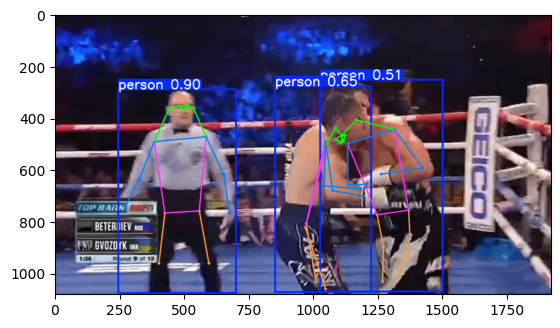

{0: {'elbow': 30.493089087786416,
  'shoulder': 98.4614347973736,
  'hip': 100.0,
  'torso': 100.0},
 1: {'elbow': 100.0, 'shoulder': 0.0, 'hip': 0.0, 'torso': 65.43825621533183},
 2: {'elbow': 100.0,
  'shoulder': 53.30128539473796,
  'hip': 87.30744322375193,
  'torso': 55.82653372159993}}

In [ ]:
test_filters(image_path)
initial_indices = cut_ghosts(result)
confident_indices = filter_by_confidence(result, initial_indices)
eliminated_indices = eliminate_overlap(result, confident_indices)
final_indices = check_anatomy(result, eliminated_indices)
generate_pseudolabels(result, final_indices)

In [ ]:
#I know this is a massive cell, but it has to be run together
import os
#this is a list of dictionaries for each person. eg: {'split': 'test', 'image_path': 'asdfajdf', etc}
csv_list = []

folders_with_splits = [
    ['/content/Boxing-1/train/images', 'train'],
    ['/content/Boxing-1/test/images', 'test'],
    ['/content/Taekwondo-Movements_2-1/train/images', 'train'],
    ['/content/Taekwondo-Movements_2-1/test/images', 'test'],
    ['/content/Taekwondo-1/train/images','train'],
    ['/content/Taekwondo-1/test/images', 'test'],
    ['/content/Taekwondo-Movements_4-1/train/images', 'train'],
    ['/content/Taekwondo-Movements_4-1/test/images', 'test'],
    ['/content/Taekwondo-Movements_1-1/train/images', 'train'],
    ['/content/Taekwondo-Movements_1-1/test/images', 'test'],
    ['/content/Taekwondo-Movements_3-1/train/images', 'train'],
    ['/content/Taekwondo-Movements_3-1/test/images', 'test'],
    ['/content/Taekwondo-Movements-1/train/images', 'train'],
    ['/content/Taekwondo-Movements-1/test/images', 'test'],
    ['/content/Taekwondo-Pose-1/train/images','train'],
    ['/content/Taekwondo-Pose-1/test/images', 'test'],
    ['/content/boxing-1/train/images', 'train'],
    ['/content/boxing-1/test/images', 'test']
]

#i used to have filter_bad_boxing, but thought it better to generalize
def return_image_list(file_path):
  #technically i don't need dirs (subfolder names), but i have to unbox into 3 variables
  #because os.walk gives 3 things and otherwise it throws an error

  for root, dirs, filenames in os.walk(file_path):
    #this is a counter i'm using purely for information; counting total boxing files
    #versus cut list after i eliminate the ringside shots
    total_files = 0
    #this could be a counter too, but for returning purposes it's cleaner to use a list; total_files
    #is never used except to print, but passed_files is used later and passed to other functions
    passed_files = []

    #this is just for the messy boxing ones
    for filename in filenames:
      total_files += 1
      if 'andre-ward' in filename.lower():
        pass
      if 'artur-beterbievs' in filename.lower():
        pass
      else:
        filepath = os.path.join(root, filename)
        passed_files.append(filepath)

  return passed_files

def add_to_csv_list(images_list, split):
  for image_path in images_list:
    #getting the intiial YOLO result and turning it into a usable list of keypoints
    image = cv2.imread(image_path)
    result = model(image)
    result = result[0]
    keypoints_list = result.keypoints.data.tolist()

    #calling the filtering pipeline i set up before
    initial_indices = cut_ghosts(result)
    confident_indices = filter_by_confidence(result, initial_indices)
    eliminated_indices = eliminate_overlap(result, confident_indices)
    final_indices = check_anatomy(result, eliminated_indices)

    #now building a dictionary for each person in the image
    image_people_dictionaries = generate_pseudolabels(result, final_indices)
    for index in image_people_dictionaries:
      person_dict = {}
      person_dict["split"] = split
      person_dict["image_path"] = str(image_path)
      person_dict["index"] = index
      person_dict["elbow"] = image_people_dictionaries[index].get("elbow")
      person_dict["shoulder"] = image_people_dictionaries[index].get("shoulder")
      person_dict["hip"] = image_people_dictionaries[index].get("hip")
      person_dict["torso"] = image_people_dictionaries[index].get("torso")
      person_dict["knee"] = image_people_dictionaries[index].get("knee")
      person_dict["overall"] = image_people_dictionaries[index].get("overall")
      #enumerate gives both index and keypoint which is just more efficient here
      #instead of having one and having to find the other every time
      for index, keypoint in enumerate(keypoints_list[index]):
        person_dict[f"kp{index}_x"] = keypoint[0]
        person_dict[f"kp{index}_y"] = keypoint[1]
        person_dict[f"kp{index}_conf"] = keypoint[2]

      csv_list.append(person_dict)

for subfolder in folders_with_splits:
  subfolder_path = subfolder[0]
  subfolder_split = subfolder[1]

  images_list = return_image_list(subfolder_path)
  add_to_csv_list(images_list, subfolder_split)

In [ ]:
import pandas as pd
pd.DataFrame(csv_list).to_csv("/content/drive/MyDrive/pseudolabels.csv", index = False)
df = pd.read_csv('/content/drive/MyDrive/pseudolabels.csv')
print(df.columns.tolist())
print(df.shape)
df['overall'].describe()

['split', 'image_path', 'index', 'elbow', 'shoulder', 'hip', 'torso', 'knee', 'overall', 'kp0_x', 'kp0_y', 'kp0_conf', 'kp1_x', 'kp1_y', 'kp1_conf', 'kp2_x', 'kp2_y', 'kp2_conf', 'kp3_x', 'kp3_y', 'kp3_conf', 'kp4_x', 'kp4_y', 'kp4_conf', 'kp5_x', 'kp5_y', 'kp5_conf', 'kp6_x', 'kp6_y', 'kp6_conf', 'kp7_x', 'kp7_y', 'kp7_conf', 'kp8_x', 'kp8_y', 'kp8_conf', 'kp9_x', 'kp9_y', 'kp9_conf', 'kp10_x', 'kp10_y', 'kp10_conf', 'kp11_x', 'kp11_y', 'kp11_conf', 'kp12_x', 'kp12_y', 'kp12_conf', 'kp13_x', 'kp13_y', 'kp13_conf', 'kp14_x', 'kp14_y', 'kp14_conf', 'kp15_x', 'kp15_y', 'kp15_conf', 'kp16_x', 'kp16_y', 'kp16_conf']
(8291, 60)


,overall
count,8291.000000
mean,73.906013
std,20.762771
min,1.977484
25%,62.638619
50%,78.679973
75%,89.550483
max,100.000000


In [ ]:
# import os
# os.chdir('/content')
# print(os.listdir('/content'))

# for root, dirs, files in os.walk('/content'):
#   print(root, len(files))

In [ ]:
#current state before website/video pipeline;

#drive mounted; so all files get saved there, not reliant on session storage; especially important for the pseudolabels
#csv, which is done and saved in my Google Drive. Plan for model; train on this CSV to get the gist of how my manual
#rules score, then test it on synthetically degraded images. More of an experiment sort of phrasing - first shipping MVP
#on bare rules.

#Current pipeline; 1) cut_ghosts filters out "people" with tiny areas, which most of the time are made up by YOLO (that's why they're called ghosts)
#2)everything cut_ghosts passes goes to filter_by_confidence which cuts out people that YOLO itself is not confident on (so if over a certain
#number of keypoints are below a confidence cutoff, then that person is just filtered out), 3)the indices filter_by_confidence passes move to
#eliminate_overlap, which compares each person to every other person in the image, and if two people's "bounding boxes" overlap over a certain
#threshold, then it just filters out both of them because YOLO is known to perform badly in these cases. Then the indices that eliminate_overlap
#passes move to 4)check_anatomy; if the ratio of certain body parts is unnatural (over 1:3, for instance), it assumes YOLO is not reliable
#in that instance and cuts out those people.

#From there, for each person index that passes all 4 of these functions; generate_pseudolabels runs them by 5 checks; knee, elbow, shoulder, hip,
#and torso;
#but the thing is, the person might be counted as confident from filter_by_confidence, but even if most of their keypoints are confident,
#their lower body might be cut out of the image or something, so i still make sure the joints i'm using are at an acceptable confidence level,
#(if they're not i just ignore that parameter and average based on the other ones)
#then run them through a calculate_angle function. From there, it's a simple check to see if it's within an acceptable range, and if it's not,
#I scale it based on how off it is, from 0 being totally awful and 100 being acceptable. I keep the scores for each joint, and an overall averaged
#score within a dictionary for that person (so {'shoulder': 34, 'torso': 66, 'overall': 55}, etc), and then each person's dictionary is
#within a bigger dictionary, with the key being their YOLO index. Then

#important to note; a person being "filtered out" doesn't mean filtered out of the image, just their index in the list of people-keypoints YOLO gives
#is ignored and the pipeline function creates a new list of indices without that person's index